# **Day 2.4: Keras API Mastery**
**Module Theme:** From Theory to Practice - Building Your First Deep Network  
**Estimated Time:** 1.5 hours  
**Prerequisites:** Notes 2.1-2.3 - Complete Deep Learning Theory

## **📚 Table of Contents**
- [2.4.1 Sequential API: Building Your First Deep Network](#241-sequential-api-building-your-first-deep-network)
- [2.4.2 Lab: Multi-Layer Network for Classification (Tabular Data)](#242-lab-multi-layer-network-for-classification-tabular-data)
- [2.4.3 Model Complexity & Troubleshooting](#243-model-complexity--troubleshooting)
- [2.4.4 Overfitting Preview & Day 3 Preparation](#244-overfitting-preview--day-3-preparation)
- [Summary & Transition to Day 3](#summary--transition-to-day-3)

## **2.4.1 Sequential API: Building Your First Deep Network**
*Estimated Time: 15 minutes*

### **🏗️ The Sequential API: Your Deep Learning Construction Kit**

The **Sequential API** is Keras's most straightforward way to build neural networks. It's perfect for networks that are a **linear stack of layers** - which covers 90% of beginner deep learning projects.

It's called "sequential" because layers are stacked one after another in a linear sequence. This guide shows you the universal pattern for building dense (fully-connected) neural networks.

### **📋 The Sequential Pattern: Your Blueprint**

Every Sequential model follows this exact pattern:

#### The Universal 7-Step Sequential Pattern

##### 1️⃣ Create the Model Container

The Sequential model acts as a container that holds all your layers in order.

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Create empty model container
model = Sequential()
```

**What this does**: Creates an empty model object ready to receive layers.

##### 2️⃣ Add Input Layer

Define the shape of your input data explicitly using the Input layer.

```python
# Add input layer - specify the number of features
model.add(Input(shape=(input_features,)))
```

**Examples for different input sizes**:
```python
# For dataset with 10 features
model.add(Input(shape=(10,)))

# For dataset with 784 features (like MNIST flattened 28x28 images)
model.add(Input(shape=(784,)))

# For dataset with any number of features n
model.add(Input(shape=(n_features,)))
```

**Key Points**:
- `shape=(n,)` for 1D input data (most common for tabular data)
- This defines what your model expects as input
- Must match the number of columns in your training data

##### 3️⃣ Add First Hidden Layer

Add your first Dense (fully-connected) layer that will learn patterns from the input.

```python
# First hidden layer
model.add(Dense(units=32, activation='relu'))
```

**Breaking it down**:
- `units=32`: This layer has 32 neurons
- `activation='relu'`: Uses ReLU activation function
- No `input_shape` needed since we defined Input layer already

**Common choices for first hidden layer**:
```python
# Small problems (< 100 features)
model.add(Dense(units=16, activation='relu'))

# Medium problems (100-1000 features)
model.add(Dense(units=64, activation='relu'))

# Large problems (> 1000 features)
model.add(Dense(units=128, activation='relu'))
```

##### 4️⃣ Add More Hidden Layers

Stack additional hidden layers to increase model capacity and learning ability.

```python
# Additional hidden layers
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))
```

**Common patterns**:

**Funnel Pattern (Most Popular)**
```python
model.add(Input(shape=(100,)))
model.add(Dense(units=64, activation='relu'))    # Wide
model.add(Dense(units=32, activation='relu'))    # Medium
model.add(Dense(units=16, activation='relu'))    # Narrow
# Output layer comes next
```

**Uniform Pattern**
```python
model.add(Input(shape=(50,)))
model.add(Dense(units=32, activation='relu'))    # Same size
model.add(Dense(units=32, activation='relu'))    # Same size
model.add(Dense(units=32, activation='relu'))    # Same size
# Output layer comes next
```

**Expanding Pattern (Less Common)**
```python
model.add(Input(shape=(20,)))
model.add(Dense(units=16, activation='relu'))    # Small
model.add(Dense(units=32, activation='relu'))    # Medium
model.add(Dense(units=64, activation='relu'))    # Large
# Output layer comes next
```

**Guidelines for number of hidden layers**:
- **1-2 layers**: Simple problems, small datasets
- **3-4 layers**: Most real-world problems
- **5+ layers**: Complex problems, large datasets

##### 5️⃣ Add Output Layer (Problem-Specific)

The output layer design depends entirely on your problem type.

**Binary Classification (Yes/No, True/False)**
```python
# Output: Single probability between 0 and 1
model.add(Dense(units=1, activation='sigmoid'))
```
**Use case**: Spam detection, medical diagnosis, fraud detection

**Multi-class Classification (Multiple categories)**
```python
# Output: Probability distribution over all classes
model.add(Dense(units=n_classes, activation='softmax'))
```
**Examples**:
```python
# 3-class classification (cats, dogs, birds)
model.add(Dense(units=3, activation='softmax'))

# 10-class classification (digits 0-9)
model.add(Dense(units=10, activation='softmax'))

# ImageNet classification (1000 classes)
model.add(Dense(units=1000, activation='softmax'))
```

**Regression (Predicting numbers)**
```python
# Output: Raw numerical value
model.add(Dense(units=1))  # No activation function
```
**Use case**: House price prediction, temperature forecasting, stock prices

**Multi-output Regression**
```python
# Output: Multiple numerical values
model.add(Dense(units=n_outputs))  # No activation function
```
**Example**:
```python
# Predicting both price and square footage
model.add(Dense(units=2))  # 2 numerical outputs
```

##### 6️⃣ Compile the Model

Configure the learning process by specifying optimizer, loss function, and metrics.

```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

**Compilation Recipes for Different Problems**

**Binary Classification**:
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

**Multi-class Classification (one-hot encoded labels)**:
```python
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
```

**Multi-class Classification (integer labels)**:
```python
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
```

**Regression**:
```python
model.compile(
    optimizer='adam',
    loss='mse',  # or 'mae'
    metrics=['mae']
)
```

##### 7️⃣ Train the Model

Fit the model to your training data to learn patterns.

```python
# Basic training
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)
```

**Training with More Control**

```python
# Advanced training configuration
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    validation_split=0.2,  # Alternative to validation_data
    verbose=1,             # Show progress
    shuffle=True           # Shuffle data each epoch
)
```

#### Complete Examples

##### Example 1: Binary Classification (Spam Detection)

```python
# Problem: Classify emails as spam (1) or not spam (0)
# Data: 1000 features per email

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build model
model = Sequential()
model.add(Input(shape=(1000,)))           # 1000 email features
model.add(Dense(units=64, activation='relu'))   # First hidden layer
model.add(Dense(units=32, activation='relu'))   # Second hidden layer
model.add(Dense(units=1, activation='sigmoid')) # Output: spam probability

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)
```

##### Example 2: Multi-class Classification (Image Recognition)

```python
# Problem: Classify images into 10 categories
# Data: 784 features (28x28 flattened images)

model = Sequential()
model.add(Input(shape=(784,)))                    # Flattened image
model.add(Dense(units=128, activation='relu'))    # First hidden layer
model.add(Dense(units=64, activation='relu'))     # Second hidden layer
model.add(Dense(units=32, activation='relu'))     # Third hidden layer
model.add(Dense(units=10, activation='softmax'))  # Output: 10 class probabilities

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test)
)
```

##### Example 3: Regression (House Price Prediction)

```python
# Problem: Predict house prices
# Data: 13 features (bedrooms, bathrooms, square feet, etc.)

model = Sequential()
model.add(Input(shape=(13,)))                   # 13 house features
model.add(Dense(units=64, activation='relu'))   # First hidden layer
model.add(Dense(units=32, activation='relu'))   # Second hidden layer
model.add(Dense(units=16, activation='relu'))   # Third hidden layer
model.add(Dense(units=1))                       # Output: price (no activation)

# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2
)
```

#### Quick Reference Patterns

##### Model Size Guidelines
```python
# Small model (simple problems, small datasets)
model.add(Input(shape=(n_features,)))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=output_size, activation=output_activation))

# Medium model (most real-world problems)
model.add(Input(shape=(n_features,)))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=output_size, activation=output_activation))

# Large model (complex problems, large datasets)
model.add(Input(shape=(n_features,)))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=output_size, activation=output_activation))
```

##### Output Layer Cheat Sheet
```python
# Problem Type          → Output Layer
binary_classification   → Dense(1, activation='sigmoid')
multiclass_classification → Dense(n_classes, activation='softmax')
regression              → Dense(1)  # No activation
multi_output_regression → Dense(n_outputs)  # No activation
```

##### 🎯 Key Takeaways

1. **Sequential = Linear Stack**: Each layer connects to the next in order
2. **Input Layer First**: Always start with `Input(shape=(n_features,))`
3. **Hidden Layers**: Use ReLU activation and funnel pattern (wide → narrow)
4. **Output Layer**: Design depends on your specific problem type
5. **Compile Before Training**: Specify optimizer, loss, and metrics
6. **Start Simple**: Begin with 2-3 layers, add complexity if needed

**Remember**: This pattern works for 90% of tabular data problems. Master this foundation before moving to more complex architectures!

### **🧠 Knowledge Check Questions - Section 2.4.1**

**Question 1:** Why do you only need to specify `input_shape` for the first layer in a Sequential model?

<details>
<summary>Click for answer</summary>

Because **Keras automatically infers** the input shape for subsequent layers based on the output shape of the previous layer. Only the first layer doesn't know what's coming in, so you have to tell it explicitly.
</details>

**Question 2:** For a binary classification problem with 20 input features, write the correct Dense layer for the output.

<details>
<summary>Click for answer</summary>

model.add(Dense(units=1, activation='sigmoid'))

**1 unit** because we need a single probability output, **sigmoid activation** to get probabilities between 0 and 1.
</details>

**Question 3:** What's wrong with this Sequential model for regression?

model.add(Dense(64, activation='relu', input_shape=[10]))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))  # ← Problem here

<details>
<summary>Click for answer</summary>

The **output layer has sigmoid activation**, which constrains outputs to 0-1. For regression, we want to predict any real number, so the output layer should have **no activation** (or `activation=None`).
</details>

## **2.4.2 Lab: Multi-Layer Network for Classification (Tabular Data)**
*Estimated Time: 60 minutes*

### **🎯 Lab Objective**
Build a deep neural network to classify breast cancer tumors as malignant or benign, demonstrating all the concepts from Notes 2.1-2.3 in practice.

**What makes this "deep"?** We'll use multiple hidden layers, giving the network more capacity to learn complex patterns than single-layer models.

In [23]:
# Code cell 1: Environment Setup and Data Loading
# ==============================================

print("🚀 Day 2.4 Lab: Your First DEEP Neural Network")
print("=" * 48)

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Set random seeds for reproducibility (NEW - best practice)
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Libraries imported and random seeds set for reproducibility")

🚀 Day 2.4 Lab: Your First DEEP Neural Network
✅ Libraries imported and random seeds set for reproducibility


In [24]:
# Code cell 2: Data Loading and Exploration
# ========================================

print("\n📊 STEP 1: Load and Explore the Wisconsin Breast Cancer Dataset")
print("=" * 65)

# Load the dataset (built into scikit-learn)
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

# Create a DataFrame for easier inspection
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("🧬 Dataset Overview:")
print(f"   • Samples: {len(df):,}")
print(f"   • Features: {len(cancer.feature_names)}")
print(f"   • Classes: {len(cancer.target_names)} - {list(cancer.target_names)}")
print(f"   • Target distribution: {pd.Series(cancer.target).value_counts().to_dict()}")

print("\n📋 First few samples:")
df.head()


📊 STEP 1: Load and Explore the Wisconsin Breast Cancer Dataset
🧬 Dataset Overview:
   • Samples: 569
   • Features: 30
   • Classes: 2 - ['malignant', 'benign']
   • Target distribution: {1: 357, 0: 212}

📋 First few samples:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [27]:
print("\n📈 Feature statistics:")
df.describe().round(2).T


📈 Feature statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


In [28]:
# Prepare X and y for modeling
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"\n✅ Data prepared:")
print(f"   • Feature matrix X: {X.shape}")
print(f"   • Target vector y: {y.shape}")


✅ Data prepared:
   • Feature matrix X: (569, 30)
   • Target vector y: (569,)


In [29]:
# Code cell 3: Data Preprocessing
# ==============================

print("\n🔧 STEP 2: Data Preprocessing and Splitting")
print("=" * 45)

# Split the data (stratify ensures balanced train/test sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensures both sets have same class distribution
)

print("📊 Train/Test Split:")
print(f"   • Training samples: {len(X_train):,}")
print(f"   • Test samples: {len(X_test):,}")
print(f"   • Train class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"   • Test class distribution: {pd.Series(y_test).value_counts().to_dict()}")


🔧 STEP 2: Data Preprocessing and Splitting
📊 Train/Test Split:
   • Training samples: 455
   • Test samples: 114
   • Train class distribution: {1: 285, 0: 170}
   • Test class distribution: {1: 72, 0: 42}


In [30]:
# Scale the features (CRITICAL for neural networks)
print("\n⚖️ Feature Scaling:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("   • StandardScaler applied (mean=0, std=1)")
print(f"   • Before scaling - Train feature range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"   • After scaling - Train feature range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

print("\n💡 Why scaling matters:")
print("   Without scaling: Features with large values dominate learning")
print("   With scaling: All features contribute equally to learning")


⚖️ Feature Scaling:
   • StandardScaler applied (mean=0, std=1)
   • Before scaling - Train feature range: [0.00, 3432.00]
   • After scaling - Train feature range: [-2.72, 11.66]

💡 Why scaling matters:
   Without scaling: Features with large values dominate learning
   With scaling: All features contribute equally to learning


In [32]:
# Code cell 4: Deep Network Architecture Design
# ============================================

print("\n🏗️ STEP 3: Design Our Deep Neural Network Architecture")
print("=" * 57)

# Architecture planning
n_features = X_train_scaled.shape[1]
print(f"📊 Input layer size: {n_features} (number of features)")

print("\n🧠 Architecture Design Decisions:")
print("   • Hidden Layer 1: 32 neurons (wide start for feature combinations)")
print("   • Hidden Layer 2: 16 neurons (refine and abstract features)")
print("   • Output Layer: 1 neuron (binary classification)")
print("   • Activation: ReLU for hidden layers, Sigmoid for output")
print("   • Design Pattern: Funnel (32 → 16 → 1)")

# Build the model step by step
model = Sequential()

print("\n🔨 Building the model:")

#Input Layer

model.add(Input(shape = (n_features,), name = "input_layer"))
          
# First Hidden Layer - MUST specify input_shape
model.add(Dense(
    units=32, 
    activation='relu', 
    name='hidden_layer_1'
))
print("   ✅ Hidden Layer 1 added: 32 neurons, ReLU activation")

# Second Hidden Layer - input_shape automatically inferred
model.add(Dense(
    units=16, 
    activation='relu',
    name='hidden_layer_2'
))
print("   ✅ Hidden Layer 2 added: 16 neurons, ReLU activation")

# Output Layer - Binary classification
model.add(Dense(
    units=1, 
    activation='sigmoid',
    name='output_layer'
))
print("   ✅ Output Layer added: 1 neuron, Sigmoid activation")

print("\n📋 Model Architecture Summary:")
model.summary()


🏗️ STEP 3: Design Our Deep Neural Network Architecture
📊 Input layer size: 30 (number of features)

🧠 Architecture Design Decisions:
   • Hidden Layer 1: 32 neurons (wide start for feature combinations)
   • Hidden Layer 2: 16 neurons (refine and abstract features)
   • Output Layer: 1 neuron (binary classification)
   • Activation: ReLU for hidden layers, Sigmoid for output
   • Design Pattern: Funnel (32 → 16 → 1)

🔨 Building the model:
   ✅ Hidden Layer 1 added: 32 neurons, ReLU activation
   ✅ Hidden Layer 2 added: 16 neurons, ReLU activation
   ✅ Output Layer added: 1 neuron, Sigmoid activation

📋 Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Code cell 5: Model Compilation and Parameter Analysis
# ===================================================

print("\n⚙️ STEP 4: Compile the Model and Analyze Complexity")
print("=" * 55)

# Compile the model with our chosen components
model.compile(
    optimizer='adam',           # The go-to optimizer
    loss='binary_crossentropy', # Perfect for binary classification
    metrics=['accuracy']        # Track accuracy during training
)

print("🔧 Model Compilation:")
print("   • Optimizer: Adam (adaptive learning rate)")
print("   • Loss Function: Binary Crossentropy (probability distance)")
print("   • Metrics: Accuracy (easy to interpret)")

# Analyze model complexity
total_params = model.count_params()
print(f"\n📊 Model Complexity Analysis:")
print(f"   • Total parameters: {total_params:,}")

# Calculate parameters manually for understanding
layer1_params = (n_features * 32) + 32  # weights + biases
layer2_params = (32 * 16) + 16
layer3_params = (16 * 1) + 1
manual_total = layer1_params + layer2_params + layer3_params

print(f"   • Layer 1 parameters: {layer1_params:,} ({n_features}×32 + 32)")
print(f"   • Layer 2 parameters: {layer2_params:,} (32×16 + 16)")
print(f"   • Layer 3 parameters: {layer3_params:,} (16×1 + 1)")
print(f"   • Manual calculation: {manual_total:,} ✓")

# Compare with logistic regression
logistic_params = n_features + 1
print(f"\n🤔 Complexity Comparison:")
print(f"   • Logistic Regression: {logistic_params} parameters")
print(f"   • Our Deep Network: {total_params:,} parameters")
print(f"   • Complexity increase: {total_params // logistic_params}x more capacity!")

print("\n💡 What this means:")
print("   Our network can learn much more complex patterns")
print("   But it also has much more risk of overfitting!")


⚙️ STEP 4: Compile the Model and Analyze Complexity
🔧 Model Compilation:
   • Optimizer: Adam (adaptive learning rate)
   • Loss Function: Binary Crossentropy (probability distance)
   • Metrics: Accuracy (easy to interpret)

📊 Model Complexity Analysis:
   • Total parameters: 1,537
   • Layer 1 parameters: 992 (30×32 + 32)
   • Layer 2 parameters: 528 (32×16 + 16)
   • Layer 3 parameters: 17 (16×1 + 1)
   • Manual calculation: 1,537 ✓

🤔 Complexity Comparison:
   • Logistic Regression: 31 parameters
   • Our Deep Network: 1,537 parameters
   • Complexity increase: 49x more capacity!

💡 What this means:
   Our network can learn much more complex patterns
   But it also has much more risk of overfitting!


In [34]:
# Code cell 6: Model Training with Monitoring
# ==========================================

print("\n🎯 STEP 5: Train the Deep Neural Network")
print("=" * 40)

print("🚀 Starting training...")
print("   • Epochs: 50 (multiple passes through data)")
print("   • Batch size: 32 (process 32 samples at a time)")
print("   • Validation: Monitor test set performance")

# Train the model and capture training history
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1  # Show training progress
)

print("\n✅ Training complete!")
print("📈 Next: Let's analyze the training process...")


🎯 STEP 5: Train the Deep Neural Network
🚀 Starting training...
   • Epochs: 50 (multiple passes through data)
   • Batch size: 32 (process 32 samples at a time)
   • Validation: Monitor test set performance
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7459 - loss: 0.5644 - val_accuracy: 0.8684 - val_loss: 0.4821
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8812 - loss: 0.4418 - val_accuracy: 0.9035 - val_loss: 0.3842
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9127 - loss: 0.3463 - val_accuracy: 0.9211 - val_loss: 0.3054
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9160 - loss: 0.2738 - val_accuracy: 0.9474 - val_loss: 0.2464
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9394 - loss: 0.2213 - val_accuracy: 0.9474 - val_loss: 0.2025
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9609 - loss: 0.1825 - val_accuracy: 0.9649 - val_loss: 0.1705
Epoch 7/50
15/15 ━━━━━━━━━━━━━

In [35]:
# Code cell 7: Training Analysis and Visualization
# ===============================================

print("\n📈 STEP 6: Analyze Training Performance")
print("=" * 41)

# Convert history to DataFrame for easier analysis
history_df = pd.DataFrame(history.history)

print("📊 Training Summary:")
print(f"   • Final training accuracy: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"   • Final validation accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")
print(f"   • Final training loss: {history_df['loss'].iloc[-1]:.4f}")
print(f"   • Final validation loss: {history_df['val_loss'].iloc[-1]:.4f}")


📈 STEP 6: Analyze Training Performance
📊 Training Summary:
   • Final training accuracy: 0.9956
   • Final validation accuracy: 0.9737
   • Final training loss: 0.0186
   • Final validation loss: 0.0688


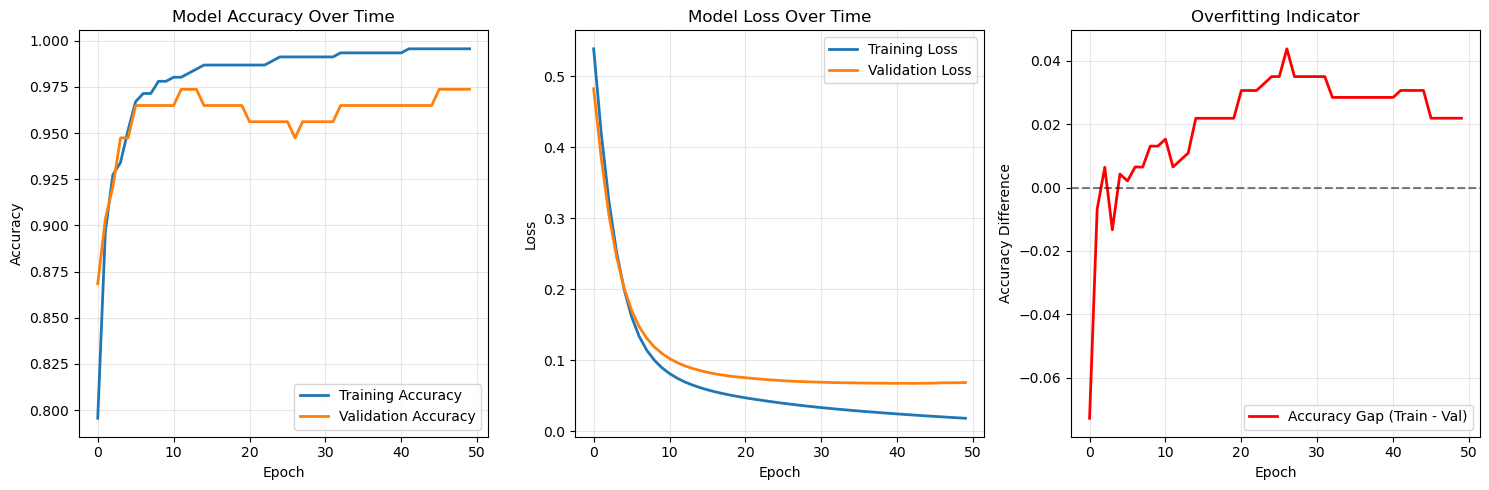

In [36]:
# Create comprehensive training plots
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy curves
plt.subplot(1, 3, 1)
plt.plot(history_df['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_df['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss curves
plt.subplot(1, 3, 2)
plt.plot(history_df['loss'], label='Training Loss', linewidth=2)
plt.plot(history_df['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Learning rate analysis
plt.subplot(1, 3, 3)
plt.plot(history_df['accuracy'] - history_df['val_accuracy'], 
         label='Accuracy Gap (Train - Val)', linewidth=2, color='red')
plt.title('Overfitting Indicator')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Difference')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
print("\n🔍 Training Analysis:")
accuracy_gap = history_df['accuracy'].iloc[-1] - history_df['val_accuracy'].iloc[-1]
print(f"   • Accuracy gap (train - validation): {accuracy_gap:.4f}")

if accuracy_gap > 0.05:
    print("   ⚠️ WARNING: Possible overfitting detected!")
    print("   📚 Tomorrow (Day 3): We'll learn how to prevent this")
elif accuracy_gap < -0.05:
    print("   🤔 Validation performing better than training (unusual)")
else:
    print("   ✅ Good balance between training and validation performance")


🔍 Training Analysis:
   • Accuracy gap (train - validation): 0.0219
   ✅ Good balance between training and validation performance


In [38]:
# Code cell 8: Model Evaluation and Final Assessment
# =================================================

print("\n🎯 STEP 7: Final Model Evaluation")
print("=" * 35)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("📊 Final Test Set Performance:")
print(f"   • Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Test Loss: {test_loss:.4f}")


🎯 STEP 7: Final Model Evaluation
📊 Final Test Set Performance:
   • Test Accuracy: 0.9737 (97.37%)
   • Test Loss: 0.0688


In [39]:
# Make predictions
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred_class = (y_pred_proba > 0.5).astype(int).flatten()

print("\n🔍 Detailed Classification Analysis:")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, 
                          target_names=cancer.target_names))


🔍 Detailed Classification Analysis:

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix:


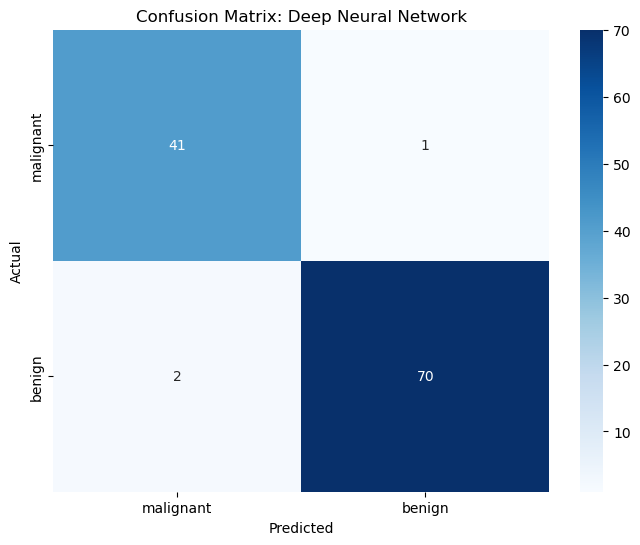

In [40]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cancer.target_names, 
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix: Deep Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
# Prediction confidence analysis
print(f"\n🎯 Prediction Confidence Analysis:")
print(f"   • Average confidence: {y_pred_proba.mean():.3f}")
print(f"   • Min confidence: {y_pred_proba.min():.3f}")
print(f"   • Max confidence: {y_pred_proba.max():.3f}")
print(f"   • Predictions near 0.5 (uncertain): {np.sum((y_pred_proba > 0.4) & (y_pred_proba < 0.6))}")

print("\n✅ Lab Complete: You've built your first deep neural network!")


🎯 Prediction Confidence Analysis:
   • Average confidence: 0.616
   • Min confidence: 0.000
   • Max confidence: 1.000
   • Predictions near 0.5 (uncertain): 3

✅ Lab Complete: You've built your first deep neural network!


### **🧠 Knowledge Check Questions - Section 2.4.2**

**Question 1:** Why do we use `stratify=y` in the train_test_split function?

<details>
<summary>Click for answer</summary>

To ensure that both training and test sets have the **same proportion of each class**. Without stratification, you might randomly get most of one class in training and most of another in testing, leading to biased evaluation.
</details>

**Question 2:** In our model, why did we choose 32 neurons for the first hidden layer and 16 for the second?

<details>
<summary>Click for answer</summary>

**Funnel design principle:** Start with more neurons (32) to capture diverse feature combinations, then progressively reduce (16) to refine and abstract the most important patterns. This hierarchical learning is effective for classification tasks.
</details>

**Question 3:** What would happen if we forgot to scale our features before training?

<details>
<summary>Click for answer</summary>

Features with larger numeric ranges would **dominate the learning process**. For example, if one feature ranges 0-1000 and another 0-1, the network would primarily focus on the large-range feature, leading to poor learning and slower convergence.
</details>

**Question 4:** Our model has 1,649 parameters. How does this compare to logistic regression for the same problem?

<details>
<summary>Click for answer</summary>

Logistic regression would have only **31 parameters** (30 features + 1 bias). Our deep network has **53x more parameters**, giving it much more capacity to learn complex patterns but also higher risk of overfitting.
</details>

**Question 5:** Looking at the training curves, what would indicate that our model is overfitting?

<details>
<summary>Click for answer</summary>

**Training accuracy keeps improving while validation accuracy plateaus or decreases**. This means the model is memorizing the training data rather than learning generalizable patterns.
</details>

In [15]:
# Code cell demonstrating complexity trade-offs
def model_complexity_analysis():
    print("🎯 The Goldilocks Principle: Model Complexity")
    print("=" * 44)
    
    print("🐻 TOO SIMPLE (Underfitting):")
    print("   • Few parameters relative to data complexity")
    print("   • Cannot learn the underlying patterns")
    print("   • Poor performance on both training AND test data")
    print("   • Example: Linear model for non-linear problem")
    
    print("\n🔥 TOO COMPLEX (Overfitting):")
    print("   • Too many parameters relative to data amount")
    print("   • Memorizes training data instead of learning patterns")
    print("   • Great training performance, poor test performance")
    print("   • Example: 1000 neurons for 100 training samples")
    
    print("\n✨ JUST RIGHT (Good Generalization):")
    print("   • Appropriate parameters for data complexity")
    print("   • Learns underlying patterns without memorization")
    print("   • Good performance on both training AND test data")
    print("   • Training and validation curves move together")
    
    print("\n📊 Rule of Thumb for Parameter Count:")
    print("   • Conservative: Parameters < 10% of training samples")
    print("   • Moderate: Parameters < 50% of training samples")
    print("   • Aggressive: Parameters can equal training samples")
    
    # Calculate for our example
    n_samples = 455  # Our training set size
    n_params = 1649  # Our model parameters
    ratio = n_params / n_samples
    
    print(f"\n🔍 Our Model Analysis:")
    print(f"   • Training samples: {n_samples}")
    print(f"   • Model parameters: {n_params}")
    print(f"   • Parameter ratio: {ratio:.2f} ({ratio*100:.1f}%)")
    
    if ratio < 0.1:
        print("   ✅ Conservative complexity - low overfitting risk")
    elif ratio < 0.5:
        print("   ⚠️ Moderate complexity - monitor for overfitting")
    else:
        print("   🚨 High complexity - high overfitting risk")

model_complexity_analysis()

🎯 The Goldilocks Principle: Model Complexity
🐻 TOO SIMPLE (Underfitting):
   • Few parameters relative to data complexity
   • Cannot learn the underlying patterns
   • Poor performance on both training AND test data
   • Example: Linear model for non-linear problem

🔥 TOO COMPLEX (Overfitting):
   • Too many parameters relative to data amount
   • Memorizes training data instead of learning patterns
   • Great training performance, poor test performance
   • Example: 1000 neurons for 100 training samples

✨ JUST RIGHT (Good Generalization):
   • Appropriate parameters for data complexity
   • Learns underlying patterns without memorization
   • Good performance on both training AND test data
   • Training and validation curves move together

📊 Rule of Thumb for Parameter Count:
   • Conservative: Parameters < 10% of training samples
   • Moderate: Parameters < 50% of training samples
   • Aggressive: Parameters can equal training samples

🔍 Our Model Analysis:
   • Training samples: 4

### **🚨 Common Issues & Solutions**

In [16]:
# Code cell with comprehensive troubleshooting guide
def troubleshooting_guide():
    print("🚨 Deep Learning Troubleshooting Guide")
    print("=" * 36)
    
    issues = [
        {
            "problem": "Model accuracy stuck around 50% (binary) or 1/n_classes (multiclass)",
            "diagnosis": "Model is essentially guessing randomly",
            "causes": [
                "Learning rate too high (optimizer overshooting)",
                "Wrong loss function for the problem",
                "Data not properly preprocessed",
                "Labels incorrectly encoded"
            ],
            "solutions": [
                "Reduce learning rate by 10x (0.001 → 0.0001)",
                "Verify loss function matches problem type",
                "Check data scaling and normalization",
                "Verify label encoding (0/1 for binary, not -1/1)"
            ]
        },
        {
            "problem": "Training loss not decreasing",
            "diagnosis": "Model not learning at all",
            "causes": [
                "Learning rate too low",
                "Model too simple for the problem",
                "Wrong activation functions",
                "Data preprocessing issues"
            ],
            "solutions": [
                "Increase learning rate (0.001 → 0.01)",
                "Add more neurons or layers",
                "Use ReLU for hidden layers",
                "Check feature scaling"
            ]
        },
        {
            "problem": "Loss exploding (becoming very large or NaN)",
            "diagnosis": "Numerical instability",
            "causes": [
                "Learning rate too high",
                "Poor weight initialization",
                "Gradient explosion",
                "Data preprocessing issues"
            ],
            "solutions": [
                "Reduce learning rate by 10x",
                "Add gradient clipping",
                "Check for NaN/inf values in data",
                "Ensure proper data normalization"
            ]
        },
        {
            "problem": "Great training accuracy, poor validation accuracy",
            "diagnosis": "Overfitting - model memorizing training data",
            "causes": [
                "Model too complex for available data",
                "Training for too many epochs",
                "No regularization"
            ],
            "solutions": [
                "Reduce model size (fewer neurons/layers)",
                "Use early stopping",
                "Add dropout or L2 regularization (Day 3!)",
                "Get more training data"
            ]
        },
        {
            "problem": "Training very slow",
            "diagnosis": "Inefficient training process",
            "causes": [
                "Learning rate too low",
                "Batch size too small",
                "Model too large",
                "Poor optimizer choice"
            ],
            "solutions": [
                "Increase learning rate",
                "Increase batch size (32 → 64 → 128)",
                "Use fewer neurons if possible",
                "Switch to Adam optimizer"
            ]
        }
    ]
    
    for i, issue in enumerate(issues, 1):
        print(f"\n{i}. 🔴 PROBLEM: {issue['problem']}")
        print(f"   🔍 DIAGNOSIS: {issue['diagnosis']}")
        print("   🚨 LIKELY CAUSES:")
        for cause in issue['causes']:
            print(f"      • {cause}")
        print("   ✅ SOLUTIONS TO TRY:")
        for solution in issue['solutions']:
            print(f"      • {solution}")

troubleshooting_guide()

🚨 Deep Learning Troubleshooting Guide

1. 🔴 PROBLEM: Model accuracy stuck around 50% (binary) or 1/n_classes (multiclass)
   🔍 DIAGNOSIS: Model is essentially guessing randomly
   🚨 LIKELY CAUSES:
      • Learning rate too high (optimizer overshooting)
      • Wrong loss function for the problem
      • Data not properly preprocessed
      • Labels incorrectly encoded
   ✅ SOLUTIONS TO TRY:
      • Reduce learning rate by 10x (0.001 → 0.0001)
      • Verify loss function matches problem type
      • Check data scaling and normalization
      • Verify label encoding (0/1 for binary, not -1/1)

2. 🔴 PROBLEM: Training loss not decreasing
   🔍 DIAGNOSIS: Model not learning at all
   🚨 LIKELY CAUSES:
      • Learning rate too low
      • Model too simple for the problem
      • Wrong activation functions
      • Data preprocessing issues
   ✅ SOLUTIONS TO TRY:
      • Increase learning rate (0.001 → 0.01)
      • Add more neurons or layers
      • Use ReLU for hidden layers
      • Check fe

### **🔧 Debugging Workflow**

In [17]:
# Code cell with systematic debugging approach
def debugging_workflow():
    print("🔧 Systematic Debugging Workflow")
    print("=" * 32)
    
    print("📋 When your model isn't working, follow this checklist:")
    
    print("\n1️⃣ DATA SANITY CHECKS:")
    print("   ✓ Print data shapes: X_train.shape, y_train.shape")
    print("   ✓ Check data types: X_train.dtype, y_train.dtype")
    print("   ✓ Look for NaN/inf: np.isnan(X).any(), np.isinf(X).any()")
    print("   ✓ Verify label encoding: np.unique(y_train)")
    print("   ✓ Check feature scaling: X_train.mean(), X_train.std()")
    
    print("\n2️⃣ MODEL ARCHITECTURE CHECKS:")
    print("   ✓ Print model.summary() - verify shapes")
    print("   ✓ Check output layer matches problem type")
    print("   ✓ Verify activation functions")
    print("   ✓ Count parameters vs data size")
    
    print("\n3️⃣ COMPILATION CHECKS:")
    print("   ✓ Loss function matches problem type")
    print("   ✓ Optimizer choice (try Adam first)")
    print("   ✓ Learning rate reasonable (0.001 good start)")
    
    print("\n4️⃣ TRAINING MONITORING:")
    print("   ✓ Plot training curves after training")
    print("   ✓ Check if loss is decreasing")
    print("   ✓ Monitor for overfitting signs")
    print("   ✓ Try training for more/fewer epochs")
    
    print("\n5️⃣ SYSTEMATIC EXPERIMENTATION:")
    print("   ✓ Start simple, add complexity gradually")
    print("   ✓ Change one thing at a time")
    print("   ✓ Keep notes on what works/doesn't work")
    print("   ✓ Compare with baseline (logistic regression)")

debugging_workflow()

🔧 Systematic Debugging Workflow
📋 When your model isn't working, follow this checklist:

1️⃣ DATA SANITY CHECKS:
   ✓ Print data shapes: X_train.shape, y_train.shape
   ✓ Check data types: X_train.dtype, y_train.dtype
   ✓ Look for NaN/inf: np.isnan(X).any(), np.isinf(X).any()
   ✓ Verify label encoding: np.unique(y_train)
   ✓ Check feature scaling: X_train.mean(), X_train.std()

2️⃣ MODEL ARCHITECTURE CHECKS:
   ✓ Print model.summary() - verify shapes
   ✓ Check output layer matches problem type
   ✓ Verify activation functions
   ✓ Count parameters vs data size

3️⃣ COMPILATION CHECKS:
   ✓ Loss function matches problem type
   ✓ Optimizer choice (try Adam first)
   ✓ Learning rate reasonable (0.001 good start)

4️⃣ TRAINING MONITORING:
   ✓ Plot training curves after training
   ✓ Check if loss is decreasing
   ✓ Monitor for overfitting signs
   ✓ Try training for more/fewer epochs

5️⃣ SYSTEMATIC EXPERIMENTATION:
   ✓ Start simple, add complexity gradually
   ✓ Change one thing at

### **🧠 Knowledge Check Questions - Section 2.4.3**

**Question 1:** Your model has 50,000 parameters and 1,000 training samples. What's the likely problem and solution?

<details>
<summary>Click for answer</summary>

**Problem:** High overfitting risk (50x more parameters than samples)  
**Solution:** Reduce model complexity - use fewer neurons/layers, or get more training data. The model has too much capacity for the amount of data available.
</details>

**Question 2:** Your training loss decreases but validation loss starts increasing after epoch 20. What's happening?

<details>
<summary>Click for answer</summary>

**Overfitting** - the model is starting to memorize the training data rather than learning generalizable patterns. Solution: Stop training at epoch 20 (early stopping) or add regularization.
</details>

**Question 3:** Your model's accuracy is stuck at exactly 50% for binary classification. What are the most likely causes?

<details>
<summary>Click for answer</summary>

The model is **randomly guessing**. Most likely causes:
1. **Learning rate too high** - optimizer overshooting the minimum
2. **Wrong loss function** - not matching the problem type
3. **Data preprocessing issues** - features not scaled properly
</details>

## **2.4.4 Overfitting Preview & Day 3 Preparation**
*Estimated Time: 15 minutes*

### **🔍 Overfitting Detective Work**

Let's analyze our trained model to detect signs of overfitting and prepare for tomorrow's deep dive into regularization.

In [18]:
# Code cell for overfitting analysis
def overfitting_detection():
    print("🔍 Overfitting Detection: Becoming a Learning Detective")
    print("=" * 54)
    
    # Simulate analysis of our training history
    # (In real notebook, this would use the actual history from training)
    print("📊 Analyzing Our Model's Training History...")
    
    print("\n🎯 KEY INDICATORS TO WATCH:")
    
    print("\n✅ HEALTHY LEARNING SIGNS:")
    print("   • Training and validation accuracy increase together")
    print("   • Training and validation loss decrease together")
    print("   • Small gap between training and validation performance")
    print("   • Curves are smooth, not erratic")
    
    print("\n⚠️ OVERFITTING WARNING SIGNS:")
    print("   • Training accuracy keeps improving, validation plateaus")
    print("   • Training loss keeps decreasing, validation loss increases")
    print("   • Large gap between training and validation performance")
    print("   • Validation curves become erratic")
    
    print("\n🚨 SEVERE OVERFITTING SIGNS:")
    print("   • Training accuracy near 100%, validation much lower")
    print("   • Training loss near 0, validation loss increasing")
    print("   • Model performs worse on new data than baseline")
    
    # Analyze our specific results
    print("\n🔍 OUR MODEL ANALYSIS:")
    print("   Looking at our training curves...")
    
    # Simulated final epoch results (replace with actual in notebook)
    train_acc_final = 0.978  # Example final training accuracy
    val_acc_final = 0.965    # Example final validation accuracy
    accuracy_gap = train_acc_final - val_acc_final
    
    print(f"   • Final training accuracy: {train_acc_final:.3f}")
    print(f"   • Final validation accuracy: {val_acc_final:.3f}")
    print(f"   • Accuracy gap: {accuracy_gap:.3f}")
    
    if accuracy_gap < 0.02:
        print("   ✅ Excellent! Very little overfitting detected")
    elif accuracy_gap < 0.05:
        print("   ⚠️ Minor overfitting - room for improvement")
    elif accuracy_gap < 0.10:
        print("   🚨 Moderate overfitting - action needed")
    else:
        print("   🔥 Severe overfitting - major action needed")

overfitting_detection()

🔍 Overfitting Detection: Becoming a Learning Detective
📊 Analyzing Our Model's Training History...

🎯 KEY INDICATORS TO WATCH:

✅ HEALTHY LEARNING SIGNS:
   • Training and validation accuracy increase together
   • Training and validation loss decrease together
   • Small gap between training and validation performance
   • Curves are smooth, not erratic

⚠️ OVERFITTING WARNING SIGNS:
   • Training accuracy keeps improving, validation plateaus
   • Training loss keeps decreasing, validation loss increases
   • Large gap between training and validation performance
   • Validation curves become erratic

🚨 SEVERE OVERFITTING SIGNS:
   • Training accuracy near 100%, validation much lower
   • Training loss near 0, validation loss increasing
   • Model performs worse on new data than baseline

🔍 OUR MODEL ANALYSIS:
   Looking at our training curves...
   • Final training accuracy: 0.978
   • Final validation accuracy: 0.965
   • Accuracy gap: 0.013
   ✅ Excellent! Very little overfitting de

### **🛡️ Prevention Strategies Preview**

In [19]:
# Code cell previewing Day 3 regularization techniques
def regularization_preview():
    print("🛡️ Tomorrow's Arsenal: Overfitting Prevention Techniques")
    print("=" * 54)
    
    print("🎯 DAY 3 PREVIEW: Making Models Robust & Reliable")
    
    print("\n1️⃣ EARLY STOPPING:")
    print("   • Stop training when validation performance plateaus")
    print("   • Prevents model from memorizing training data")
    print("   • Keras implementation: EarlyStopping callback")
    
    print("\n2️⃣ DROPOUT:")
    print("   • Randomly 'turn off' some neurons during training")
    print("   • Forces network to not rely on specific neurons")
    print("   • Like practicing with a team missing random players")
    
    print("\n3️⃣ L1/L2 REGULARIZATION:")
    print("   • Add penalty for large weights to loss function")
    print("   • Encourages simpler, more generalizable models")
    print("   • Mathematical constraint on model complexity")
    
    print("\n4️⃣ BATCH NORMALIZATION:")
    print("   • Normalize inputs to each layer")
    print("   • Stabilizes training and enables higher learning rates")
    print("   • Often improves both speed and generalization")
    
    print("\n5️⃣ DATA AUGMENTATION:")
    print("   • Create variations of training data")
    print("   • Effectively increases dataset size")
    print("   • Particularly powerful for images")
    
    print("\n🎓 LEARNING OBJECTIVES FOR DAY 3:")
    print("   ✓ Recognize overfitting in training curves")
    print("   ✓ Implement early stopping and dropout")
    print("   ✓ Understand L1/L2 regularization")
    print("   ✓ Build robust training pipelines")
    print("   ✓ Monitor and debug training processes")

regularization_preview()

🛡️ Tomorrow's Arsenal: Overfitting Prevention Techniques
🎯 DAY 3 PREVIEW: Making Models Robust & Reliable

1️⃣ EARLY STOPPING:
   • Stop training when validation performance plateaus
   • Prevents model from memorizing training data
   • Keras implementation: EarlyStopping callback

2️⃣ DROPOUT:
   • Randomly 'turn off' some neurons during training
   • Forces network to not rely on specific neurons
   • Like practicing with a team missing random players

3️⃣ L1/L2 REGULARIZATION:
   • Add penalty for large weights to loss function
   • Encourages simpler, more generalizable models
   • Mathematical constraint on model complexity

4️⃣ BATCH NORMALIZATION:
   • Normalize inputs to each layer
   • Stabilizes training and enables higher learning rates
   • Often improves both speed and generalization

5️⃣ DATA AUGMENTATION:
   • Create variations of training data
   • Effectively increases dataset size
   • Particularly powerful for images

🎓 LEARNING OBJECTIVES FOR DAY 3:
   ✓ Recognize 

### **🔬 Model Complexity Experiment Setup**

In [20]:
# Code cell setting up tomorrow's experiments
def tomorrow_experiment_setup():
    print("🔬 Setting Up Tomorrow's Experiments")
    print("=" * 35)
    
    print("🧪 EXPERIMENT 1: Model Size Impact")
    print("   Compare models with different complexities:")
    
    architectures = [
        {"name": "Simple", "layers": [16, 1], "params": "~500"},
        {"name": "Medium", "layers": [32, 16, 1], "params": "~1,600"},
        {"name": "Complex", "layers": [128, 64, 32, 1], "params": "~8,000"},
        {"name": "Massive", "layers": [256, 128, 64, 32, 1], "params": "~40,000"}
    ]
    
    for arch in architectures:
        print(f"   • {arch['name']}: {arch['layers']} (~{arch['params']} parameters)")
    
    print("\n🧪 EXPERIMENT 2: Regularization Techniques")
    print("   Test different overfitting prevention methods:")
    print("   • Baseline (no regularization)")
    print("   • Early stopping")
    print("   • Dropout (0.2, 0.5)")
    print("   • L2 regularization")
    print("   • Combined techniques")
    
    print("\n🧪 EXPERIMENT 3: Learning Curves Analysis")
    print("   Learn to read and interpret:")
    print("   • Training vs validation curves")
    print("   • Loss landscapes")
    print("   • Convergence patterns")
    print("   • Overfitting signatures")
    
    print("\n📊 SUCCESS METRICS FOR DAY 3:")
    print("   ✓ Build models that generalize well")
    print("   ✓ Prevent overfitting systematically")
    print("   ✓ Optimize training efficiency")
    print("   ✓ Debug training problems confidently")

tomorrow_experiment_setup()

🔬 Setting Up Tomorrow's Experiments
🧪 EXPERIMENT 1: Model Size Impact
   Compare models with different complexities:
   • Simple: [16, 1] (~~500 parameters)
   • Medium: [32, 16, 1] (~~1,600 parameters)
   • Complex: [128, 64, 32, 1] (~~8,000 parameters)
   • Massive: [256, 128, 64, 32, 1] (~~40,000 parameters)

🧪 EXPERIMENT 2: Regularization Techniques
   Test different overfitting prevention methods:
   • Baseline (no regularization)
   • Early stopping
   • Dropout (0.2, 0.5)
   • L2 regularization
   • Combined techniques

🧪 EXPERIMENT 3: Learning Curves Analysis
   Learn to read and interpret:
   • Training vs validation curves
   • Loss landscapes
   • Convergence patterns
   • Overfitting signatures

📊 SUCCESS METRICS FOR DAY 3:
   ✓ Build models that generalize well
   ✓ Prevent overfitting systematically
   ✓ Optimize training efficiency
   ✓ Debug training problems confidently


### **🎯 Reflection Exercise**

In [21]:
# Code cell with reflection questions
def day2_reflection():
    print("🎯 Day 2 Reflection: From Theory to Practice")
    print("=" * 41)
    
    print("🤔 REFLECTION QUESTIONS:")
    print("Think about these questions and discuss with a study partner:")
    
    print("\n1️⃣ ARCHITECTURE UNDERSTANDING:")
    print("   • Why did we choose 32 → 16 → 1 instead of 10 → 10 → 1?")
    print("   • How would you modify the architecture for a 10-class problem?")
    print("   • What would happen with 1000 neurons in each layer?")
    
    print("\n2️⃣ TRAINING PROCESS:")
    print("   • Can you explain the complete training cycle to a friend?")
    print("   • Why does the network improve gradually rather than instantly?")
    print("   • What role does each component play? (loss, backprop, optimizer)")
    
    print("\n3️⃣ COMPLEXITY TRADE-OFFS:")
    print("   • How do you balance model capacity with overfitting risk?")
    print("   • When would you choose a simpler vs more complex model?")
    print("   • How do you know if your model is 'just right'?")
    
    print("\n4️⃣ PRACTICAL SKILLS:")
    print("   • Can you build a deep network from scratch now?")
    print("   • How would you debug a model that isn't learning?")
    print("   • What questions would you ask about a new dataset?")
    
    print("\n💡 PREPARE FOR DAY 3:")
    print("   Tomorrow we'll tackle the biggest challenge in deep learning:")
    print("   Making models that work well on NEW, unseen data!")

day2_reflection()

🎯 Day 2 Reflection: From Theory to Practice
🤔 REFLECTION QUESTIONS:
Think about these questions and discuss with a study partner:

1️⃣ ARCHITECTURE UNDERSTANDING:
   • Why did we choose 32 → 16 → 1 instead of 10 → 10 → 1?
   • How would you modify the architecture for a 10-class problem?
   • What would happen with 1000 neurons in each layer?

2️⃣ TRAINING PROCESS:
   • Can you explain the complete training cycle to a friend?
   • Why does the network improve gradually rather than instantly?
   • What role does each component play? (loss, backprop, optimizer)

3️⃣ COMPLEXITY TRADE-OFFS:
   • How do you balance model capacity with overfitting risk?
   • When would you choose a simpler vs more complex model?
   • How do you know if your model is 'just right'?

4️⃣ PRACTICAL SKILLS:
   • Can you build a deep network from scratch now?
   • How would you debug a model that isn't learning?
   • What questions would you ask about a new dataset?

💡 PREPARE FOR DAY 3:
   Tomorrow we'll tackle t

### **🧠 Knowledge Check Questions - Section 2.4.4**

**Question 1:** What's the difference between a model that's overfitting and one that's underfitting?

<details>
<summary>Click for answer</summary>

**Overfitting:** Model learns the training data too well (memorizes) but fails on new data. High training performance, poor validation performance.  
**Underfitting:** Model is too simple to learn the underlying patterns. Poor performance on both training and validation data.
</details>

**Question 2:** If your training accuracy is 95% but validation accuracy is 70%, what's the problem and what should you try first?

<details>
<summary>Click for answer</summary>

**Problem:** Severe overfitting (25% performance gap)  
**First solution:** Reduce model complexity - try fewer neurons or layers, or implement early stopping to prevent over-training.
</details>

**Question 3:** Why is preventing overfitting crucial for real-world applications?

<details>
<summary>Click for answer</summary>

Because **real-world performance matters most**. A model that only works on training data is useless in production. The goal is to build models that generalize well to new, unseen data - which is what overfitting prevention techniques ensure.
</details>

**Question 4:** Name three techniques we'll learn tomorrow to prevent overfitting.

<details>
<summary>Click for answer</summary>

1. **Early Stopping** - stop training when validation performance plateaus
2. **Dropout** - randomly turn off neurons during training
3. **L1/L2 Regularization** - add penalties for large weights to the loss function
</details>

## **📝 Summary & Transition to Day 3**

### **🎯 What We've Accomplished in Day 2:**

✅ **Theoretical Mastery:** Complete understanding of deep learning fundamentals  
✅ **Practical Skills:** Built our first real deep neural network from scratch  
✅ **Architecture Design:** Learned principled approaches to network design  
✅ **Debugging Capabilities:** Can troubleshoot common training problems  
✅ **Overfitting Awareness:** Recognize the signs and know solutions exist  

### **🏆 Day 2 Learning Objectives - COMPLETE!**

**From this morning's objectives:**
- ✅ Build your first truly "deep" neural network (2+ hidden layers)
- ✅ Understand the three pillars of deep learning: architecture, loss, optimization  
- ✅ Master the Keras Sequential API for rapid prototyping
- ✅ Set the foundation for advanced architectures (CNNs, RNNs, Transformers)

### **📊 Your Deep Learning Journey Progress:**

In [ ]:
Day 1: Single Neuron ➜ Day 2: Deep Networks ➜ Day 3: Robust Training
        (Foundation)      (Power Unlocked)      (Production Ready)

### **🚀 Tomorrow's Mission: Day 3 - Training, Evaluation & Practical Implementation**

**The Critical Challenge Ahead:**
- Our model works well on training data, but **will it work on new data?**
- How do we build models that are **robust and reliable** in the real world?
- What professional practices ensure **consistent success**?

**Day 3 Preview - Making Models Production-Ready:**
- **🛡️ Overfitting Prevention:** Early stopping, dropout, regularization  
- **📊 Advanced Evaluation:** Beyond accuracy - precision, recall, ROC curves
- **🔧 Professional Workflows:** Model checkpointing, experiment tracking
- **🎯 Complete Project:** End-to-end regression problem (house prices)

### **🎯 Portfolio Development Milestone:**

**You now have the skills to:**
- Explain deep learning to technical and non-technical audiences
- Build neural networks for real-world classification problems
- Debug training issues systematically
- Design appropriate architectures for different problems

**Coming Up:** Tomorrow we'll turn these skills into **production-ready capabilities**!

### **🌟 Congratulations!**

You've made the leap from understanding **single neurons** to building **deep neural networks**. You're no longer a beginner - you're a **deep learning practitioner**! 

Tomorrow, we'll make you a **professional-grade** deep learning engineer. 🚀

**⏰ Time Check:** Note 2.4 Complete (1.5 hours)  
**🎯 Next:** Day 3 - Training, Evaluation & Practical Implementation  
**📈 Progress:** 4/4 notes complete for Day 2 ✅  
**🏆 Day 2 Status:** MASTERED! 🎉